# Dissertation Update - March 4th

tldr: code has been updated to reflect the bottlenecks and removing of all human characteristics except congestion.

| Original Question | New Potential Question |
| ----------------- | ---------------------- |
| Can incorporating human-inspired heuristics into the operators of a genetic algorithm lead to more realistic evacuation routing patterns compared to a standard GA and a greedy in multi-agent evacuation modelling? | Does globally optimised mult-agent routing via Genetic Algorithms produce better evacuation outcomes than individual greedy path routing? |


In [1]:
%load_ext autoreload
%autoreload 2

## City Creation
We need to compare the performance of the algorithms against each other. In order to understand the different classifications for each city I have considered the following metrics:

| Metric | Description | Calculation | Hypothesis |
| ------ | ----------- | ----------- | ---------- |
| Betweeness | For every node in the graph the betweeness measures what fraction of the shortest paths between all other nodes this node is in.| The maximum betweeness of all nodes is taken | Higher numbers represent bottlenecks, where GA is expected to have a larger improvement. |
| Articulation Points | This is where we have nodes which if removed would disconnect the graph, this could result in some agents not having exit routes. |  | The higher the value the more sensitive the city, this value is expected to be higher in constrained cities. |
| Average Path Length | For all non-exit nodes find the shortest path to any exit | Averaged across all nodes. | The longer the shortest path the more change of congestion. |
| Node Connectivity | The minimum number of nodes you need to disconnect the graph. | | The lower this value the more likely to cause bottlenecks, so the higher the value the more flexible the route. |
| Exit Ratio | The number of exits available relative to the number of agents evacuating, representing how much pressure the exits are under. | The number of exits divided by the number of agents. | Lower ratios mean more agents competing for fewer exits - greedy agents will cluster at nearest exits. |

In [11]:
import pickle

from utils.environment import Environment 
from city_creation_v2 import calculate_metrics, visualise_single_city

def read_pickle(name: str) -> tuple:
    with open(f"graphs/{name}.pkl", "rb") as f:
        city = pickle.load(f)

    G      = city["graph"]
    exits  = city["exits"]
    starts = city["starts"]
    metrics = city["metrics"]
    return G, exits, starts, metrics


In [78]:
constrained_city_name = 'constrained_1'
(
    G_constrained, exits_constrained, starts_constrained, metrics_constrained
) = read_pickle(constrained_city_name)
# visualise_single_city(G_constrained, exits_constrained, starts_constrained, constrained_city_name)

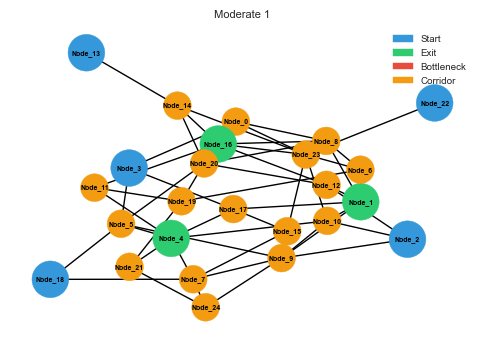

In [76]:
moderate_city_name = 'moderate_1'
(
    G_moderate, exits_moderate, starts_moderate, metrics_moderate
) = read_pickle(moderate_city_name)
visualise_single_city(G_moderate, exits_moderate, starts_moderate, moderate_city_name)


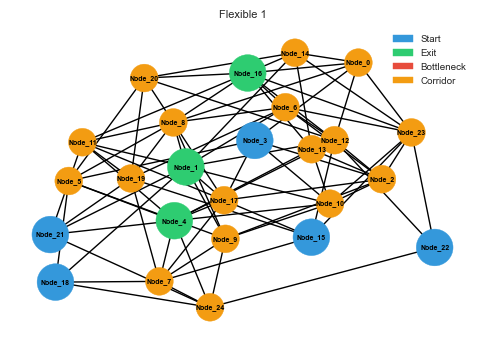

In [77]:
flexible_city_name = 'flexible_1'
(
    G_flexible, exits_flexible, starts_flexible, metrics_flexible
) = read_pickle(flexible_city_name)
visualise_single_city(G_flexible, exits_flexible, starts_flexible, flexible_city_name)


In [30]:
import pandas as pd

full_metrics = pd.DataFrame([
    metrics_constrained, metrics_moderate, metrics_flexible
])
full_metrics['City Name'] = [constrained_city_name, moderate_city_name, flexible_city_name]
full_metrics[['City Name', 'max_betweenness', 'articulation_points', 'avg_path_length', 'node_connectivity', 'exit_ratio']]

,City Name,max_betweenness,articulation_points,avg_path_length,node_connectivity,exit_ratio
0,constrained_1,0.474,5,1.77,1,0.06
1,moderate_1,0.205,2,1.36,1,0.06
2,flexible_1,0.093,0,1.23,3,0.06


The idea is as the city becomes less constraied the GA advantage should shrink (Constrained → Moderate → Flexible).

## Algorithm Performance

In [57]:
import numpy as np
from tqdm import tqdm


n_experiments = 10
rng = np.random.default_rng(42)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

num_agents = 50
simulation_params = {"congestion": True, "walking": False, "fitness": "max"}

In [47]:
from utils.environment import Environment 
from utils.algorithm_evaluation import AlgorithmComparison
from multi_agent_ga import simulate_ga_evacuation, simulate_greedy_evacuation

### Constrained City

In [48]:
city = Environment(city_name=constrained_city_name)

In [50]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: constrained_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 15.000 | avg fit: 16.860 | worst fit: 19.000 | avg path: 3.388 | congestion: 8.232 | exit use: 0.136 | diveristy: 0.022
Evolution    5 | best fit: 14.000 | avg fit: 16.020 | worst fit: 19.000 | avg path: 3.332 | congestion: 8.138 | exit use: 0.133 | diveristy: 0.061
Evolution   10 | best fit: 14.000 | avg fit: 15.060 | worst fit: 17.000 | avg path: 3.270 | congestion: 7.794 | exit use: 0.113 | diveristy: 0.090
Evolution   15 | best fit: 14.000 | avg fit: 14.840 | worst fit: 16.000 | avg path: 3.279 | congestion: 7.718 | exit use: 0.111 | diveristy: 0.116
Evolution   20 | best fit: 14.000 | avg fit: 1

In [51]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.68 | Total time: 20.00 | Average time: 15.68 | Exit utilisation: 0.19 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 13.00


In [58]:
city = Environment(city_name=constrained_city_name)

greedy_outputs, ga_outputs = [], []
for seed_idx in tqdm(range(n_experiments)):
    _ , greedy_evaluation = simulate_greedy_evacuation(
        num_agents=num_agents,
        simulation_params=simulation_params,
        algorithm_seed=algorithm_seeds[seed_idx],
        city=city,
        verbose=False
    )
    greedy_outputs.append(greedy_evaluation)
    
    _ , ga_evaluation = simulate_ga_evacuation(
        city=city,
        num_agents=num_agents,
        population_size=50,
        algorithm_seed=algorithm_seeds[seed_idx],
        max_evolutions=50,
        simulation_params=simulation_params,
        verbose=0,
    )
    ga_outputs.append(ga_evaluation) 
            

100%|██████████| 10/10 [07:24<00:00, 44.44s/it]


In [59]:
comparison = AlgorithmComparison(greedy_outputs=greedy_outputs, ga_outputs=ga_outputs)
results = comparison.statistical_tests(verbose=True)

Total time p-value: 0.002 (Significant: True)
Average time p-value: 0.002 (Significant: True)
Avg Congestion delay p-value: 0.002 (Significant: True)
Exit utilisation p-value: 1.000 (Significant: False)
Avg Path Efficiency p-value: 0.002 (Significant: True)


In [60]:
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 1.844 ± 0.292


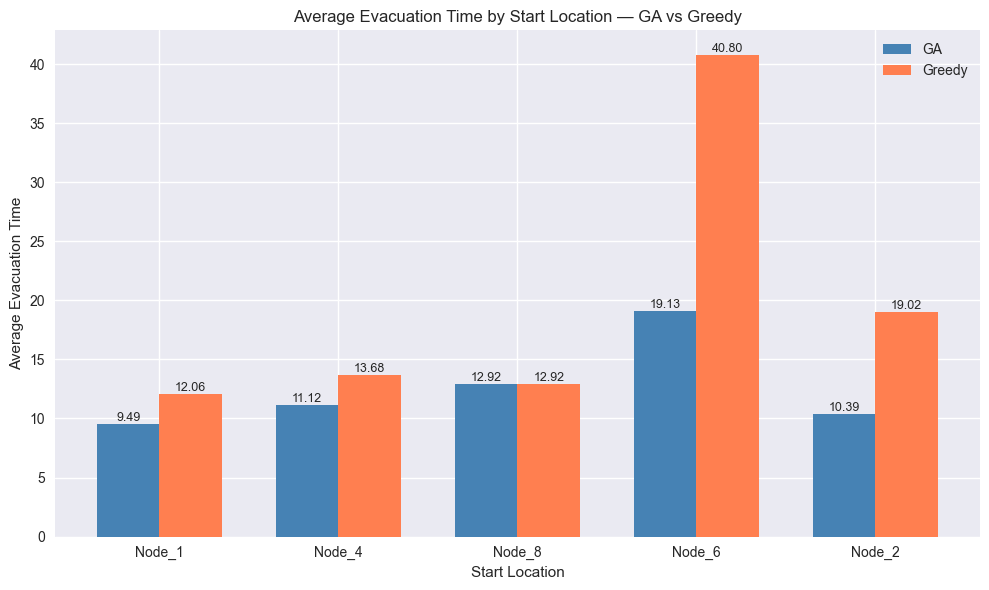

In [62]:
comparison.plot_exit_time_by_start_location()


### Moderate City

In [63]:
city = Environment(city_name=moderate_city_name)

In [70]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: flexible_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 20.000 | avg fit: 21.860 | worst fit: 22.000 | avg path: 4.548 | congestion: 7.322 | exit use: 0.133 | diveristy: 0.043
Evolution    5 | best fit: 20.000 | avg fit: 21.360 | worst fit: 24.000 | avg path: 4.611 | congestion: 7.280 | exit use: 0.142 | diveristy: 0.187
Evolution   10 | best fit: 19.000 | avg fit: 20.880 | worst fit: 24.000 | avg path: 4.673 | congestion: 7.090 | exit use: 0.155 | diveristy: 0.245
Evolution   15 | best fit: 19.000 | avg fit: 20.540 | worst fit: 23.000 | avg path: 4.761 | congestion: 6.890 | exit use: 0.130 | diveristy: 0.301
Evolution   20 | best fit: 18.000 | avg fit: 19.9

In [71]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.54 | Total time: 39.00 | Average time: 33.30 | Exit utilisation: 0.00 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 30.76


In [72]:
comparison = AlgorithmComparison(
    greedy_outputs=[greedy_evaluation], ga_outputs=[ga_evaluation]
)
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 2.600 ± 0.000


### Flexible

In [66]:
city = Environment(city_name=flexible_city_name)

In [67]:
ga_solution, ga_evaluation = simulate_ga_evacuation(
    city=city,
    num_agents=num_agents,
    population_size=50,
    algorithm_seed=algorithm_seeds[0],
    max_evolutions=50,
    simulation_params={"congestion": True, "walking": False, "fitness": "max"},
    verbose=5,
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: flexible_1 | Population size: 50 | Walking Speed: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 20.000 | avg fit: 21.860 | worst fit: 22.000 | avg path: 4.548 | congestion: 7.322 | exit use: 0.133 | diveristy: 0.043
Evolution    5 | best fit: 20.000 | avg fit: 21.360 | worst fit: 24.000 | avg path: 4.611 | congestion: 7.280 | exit use: 0.142 | diveristy: 0.187
Evolution   10 | best fit: 19.000 | avg fit: 20.880 | worst fit: 24.000 | avg path: 4.673 | congestion: 7.090 | exit use: 0.155 | diveristy: 0.245
Evolution   15 | best fit: 19.000 | avg fit: 20.540 | worst fit: 23.000 | avg path: 4.761 | congestion: 6.890 | exit use: 0.130 | diveristy: 0.301
Evolution   20 | best fit: 18.000 | avg fit: 19.9

In [68]:
greedy_solution, greedy_evaluation = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=simulation_params,
    algorithm_seed=algorithm_seeds[0],
    city=city,
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 2.54 | Total time: 39.00 | Average time: 33.30 | Exit utilisation: 0.00 | Avg Path Efficiency: 1.00 | Congestion index: 100% | Avg Congestion delay: 30.76


In [69]:
comparison = AlgorithmComparison(
    greedy_outputs=[greedy_evaluation], ga_outputs=[ga_evaluation]
)
price_of_anarchy = comparison.price_of_anarchy(verbose=True)

Price of Anarchy: 2.600 ± 0.000


## Compliance Rate
How does the genetic algorithm's advantage change with compliance rate?

* Do this after calculated the routes and change some agents (i.e. the genetic algorithm doesn't know about the non-compliance).
* run this for different non-compliance rates (where 0% is ga and 100% is greedy). 